# 1. Carregar e Inspecionar os Dados

Nesta etapa, o objetivo é carregar o dataset de concentração atmosférica de CO₂ e realizar uma inspeção inicial da estrutura dos dados.

Serão verificados:
- primeiras observações;
- quantidade de linhas e colunas;
- tipos de dados;
- estrutura do índice temporal.

In [9]:
import pandas as pd
import statsmodels.api as sm

df = sm.datasets.co2.load_pandas().data

print(df.head())
print("="*30)
print(df.shape)
print("="*30)
print(df.info())

              co2
1958-03-29  316.1
1958-04-05  317.3
1958-04-12  317.6
1958-04-19  317.5
1958-04-26  316.4
(2284, 1)
<class 'pandas.DataFrame'>
DatetimeIndex: 2284 entries, 1958-03-29 to 2001-12-29
Freq: W-SAT
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   co2     2225 non-null   float64
dtypes: float64(1)
memory usage: 35.7 KB
None


## 2. Verificar o Índice Temporal

Nesta etapa, verificamos se o índice está em formato temporal, se os registros estão ordenados cronologicamente e qual é a frequência da série.

In [10]:
print(type(df.index))
print(f"Ordenado: {df.index.is_monotonic_increasing}")
print(f"Frequência: {pd.infer_freq(df.index)}")

<class 'pandas.DatetimeIndex'>
Ordenado: True
Frequência: W-SAT


### Observações

O índice está no formato `DatetimeIndex`, os dados estão ordenados corretamente e a frequência identificada é **semanal aos sábados (`W-SAT`)**.

## 3. Verificar Problemas Básicos

Nesta etapa, são verificados valores ausentes, datas duplicadas e estatísticas descritivas da variável `co2`.

In [11]:
print("Valores Ausentes")
print(df.isna().sum())

print("\nDatas duplicadas:")
print(df.index.duplicated().sum())

print("\nEstatísticas:")
print(df.describe())

Valores Ausentes
co2    59
dtype: int64

Datas duplicadas:
0

Estatísticas:
               co2
count  2225.000000
mean    340.142247
std      17.003885
min     313.000000
25%     324.800000
50%     338.300000
75%     354.800000
max     373.900000


### Observações

Foram identificados **59 valores ausentes** na variável `co2` e **nenhuma data duplicada**.

As estatísticas descritivas também ajudam a verificar a faixa de valores e o comportamento geral da série antes do tratamento.

## 4. Tratando Valores Ausentes

Foram identificados **59 valores ausentes** na variável `co2`.

Nesta etapa, as datas afetadas são analisadas e os valores ausentes são tratados por meio de interpolação temporal.

In [12]:
valores_ausentes = df[df['co2'].isna()]

print(f"Total de valores ausentes: {len(valores_ausentes)}")
print("\nDatas com valores ausentes:")
print(valores_ausentes)

Total de valores ausentes: 59

Datas com valores ausentes:
            co2
1958-05-10  NaN
1958-05-31  NaN
1958-06-07  NaN
1958-06-14  NaN
1958-06-21  NaN
1958-06-28  NaN
1958-08-23  NaN
1958-09-13  NaN
1958-09-20  NaN
1958-09-27  NaN
1958-10-04  NaN
1958-10-11  NaN
1958-10-18  NaN
1958-10-25  NaN
1958-11-01  NaN
1959-02-07  NaN
1959-03-14  NaN
1959-05-30  NaN
1959-08-15  NaN
1962-08-25  NaN
1962-09-01  NaN
1962-09-08  NaN
1962-12-29  NaN
1963-02-16  NaN
1963-05-04  NaN
1963-11-23  NaN
1964-01-25  NaN
1964-02-01  NaN
1964-02-08  NaN
1964-02-15  NaN
1964-02-22  NaN
1964-02-29  NaN
1964-03-07  NaN
1964-03-14  NaN
1964-03-21  NaN
1964-03-28  NaN
1964-04-04  NaN
1964-04-11  NaN
1964-04-18  NaN
1964-04-25  NaN
1964-05-02  NaN
1964-05-09  NaN
1964-05-16  NaN
1964-05-23  NaN
1964-06-13  NaN
1964-06-20  NaN
1964-08-08  NaN
1966-07-16  NaN
1966-07-23  NaN
1966-07-30  NaN
1966-11-05  NaN
1967-01-21  NaN
1967-01-28  NaN
1976-06-26  NaN
1984-03-31  NaN
1984-04-07  NaN
1984-04-14  NaN
1984-04-21  N

### 4.2 Tratamento dos Valores Ausentes

Antes de realizar o tratamento, foi criada uma cópia do dataset e os valores originais da variável `co2` foram preservados para permitir a comparação após o preenchimento.

Os valores ausentes foram tratados utilizando **interpolação temporal** com `method="time"`, que estima os valores considerando as observações conhecidas antes e depois do ponto ausente e a distância entre as datas no índice temporal.

Após a interpolação, os valores originalmente ausentes são comparados com os valores estimados para verificar o resultado do tratamento.

In [14]:
# Preservando os valores originais antes de fazer o tratamento
df_clean = df.copy()

df_clean["co2_original"] = df_clean["co2"]

In [15]:
df_clean["co2"] = df_clean["co2"].interpolate(
    method="time"
)

In [16]:
valores_interpolate = df_clean.loc[
    df_clean["co2_original"].isna(),
    ["co2_original", "co2"]
]

print(valores_interpolate)

            co2_original         co2
1958-05-10           NaN  317.200000
1958-05-31           NaN  317.550000
1958-06-07           NaN  317.200000
1958-06-14           NaN  316.850000
1958-06-21           NaN  316.500000
1958-06-28           NaN  316.150000
1958-08-23           NaN  314.550000
1958-09-13           NaN  313.444444
1958-09-20           NaN  313.388889
1958-09-27           NaN  313.333333
1958-10-04           NaN  313.277778
1958-10-11           NaN  313.222222
1958-10-18           NaN  313.166667
1958-10-25           NaN  313.111111
1958-11-01           NaN  313.055556
1959-02-07           NaN  316.150000
1959-03-14           NaN  316.750000
1959-05-30           NaN  318.450000
1959-08-15           NaN  314.950000
1962-08-25           NaN  317.200000
1962-09-01           NaN  317.000000
1962-09-08           NaN  316.800000
1962-12-29           NaN  318.300000
1963-02-16           NaN  319.100000
1963-05-04           NaN  321.900000
1963-11-23           NaN  317.300000
1

### 4.3 Validação Após o Tratamento

Após a interpolação, foi realizada uma nova validação para confirmar a qualidade dos dados.

Os **59 valores ausentes foram totalmente preenchidos**, mantendo as **2.284 observações originais**, sem datas duplicadas e com o índice temporal corretamente ordenado.

O período da série também foi preservado, de **1958-03-29 até 2001-12-29**, indicando que os dados estão prontos para a etapa de análise exploratória.

In [18]:
print("Antes do tratamento:")
print(df["co2"].isna().sum())

print("\nDepois do tratamento:")
print(df_clean["co2"].isna().sum())

Antes do tratamento:
59

Depois do tratamento:
0


In [21]:
print("Observações:", len(df_clean))
print("Missing:", df_clean["co2"].isna().sum())
print("Duplicadas:", df_clean.index.duplicated().sum())
print("Ordenado:", df_clean.index.is_monotonic_increasing)
print("Período:", df_clean.index.min().date(), "até", df_clean.index.max().date())

Observações: 2284
Missing: 0
Duplicadas: 0
Ordenado: True
Período: 1958-03-29 até 2001-12-29


## 5. Análise Gráfica da Série

Por fim, foi realizada uma visualização da série temporal após o tratamento dos valores ausentes.

No gráfico, é possível comparar a série tratada (`co2`) com a série original (`co2_original`). Essa comparação permite observar o comportamento geral da concentração atmosférica de CO₂ ao longo do tempo e identificar visualmente os pontos em que havia valores ausentes na base original.

A análise gráfica mostra uma **tendência crescente de longo prazo**, além de um **padrão sazonal recorrente**. Também é possível perceber que os valores interpolados acompanharam o comportamento natural da série, sem provocar distorções visuais relevantes.

Matplotlib is building the font cache; this may take a moment.


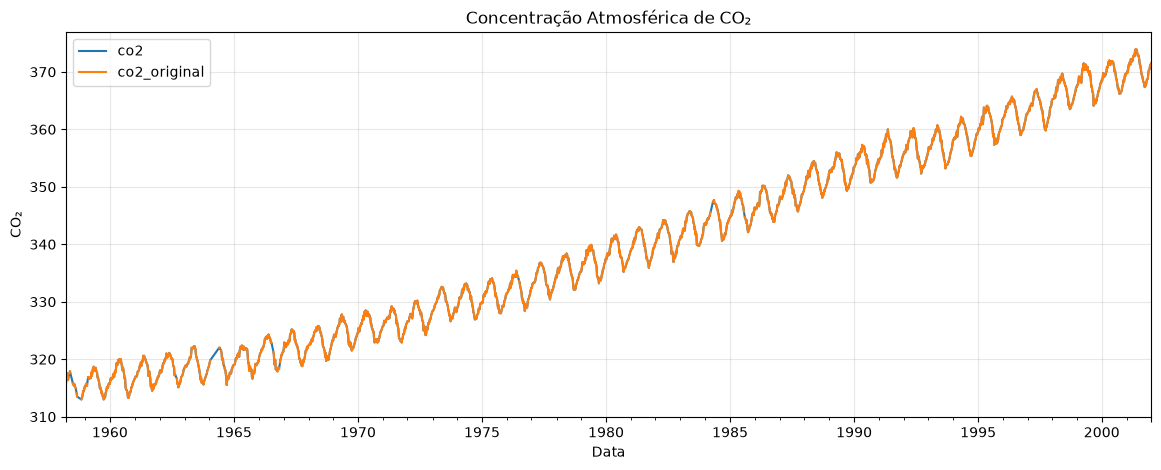

In [22]:
import matplotlib.pyplot as plt

df_clean.plot(
    figsize=(14, 5),
    title="Concentração Atmosférica de CO₂"
)

plt.xlabel("Data")
plt.ylabel("CO₂")
plt.grid(alpha=0.3)
plt.show()

## 6. Exportação dos Dados Tratados

Após as etapas de validação e tratamento, o dataset final é salvo para ser utilizado nas próximas etapas do projeto.

A versão exportada contém apenas a série de CO₂ já tratada, preservando o índice temporal e sem valores ausentes.

In [25]:
# Mantendo apenas a série tratada
df_final = df_clean['co2'].copy()

print(df_final.head())

1958-03-29    316.1
1958-04-05    317.3
1958-04-12    317.6
1958-04-19    317.5
1958-04-26    316.4
Freq: W-SAT, Name: co2, dtype: float64


In [26]:
# Salvando o dataset
df_final.to_csv("co2_clean.csv", index=True)